# Video Inpainting Clean Notebook — Local Clip + Stable Diffusion Inpainting

This notebook is cleaned to avoid the old debugging branches. It uses the same simple workflow that worked for the Nintendo clip, but swaps in the selected anime clip/frame.

**Run order:**
1. Setup paths/device
2. Load the chosen clip/frame
3. Build a more accurate mask
4. Load `inpaint_pipe`
5. Run single-frame inpainting
6. Optional: run frame-by-frame GIF and guided comparison

No AnimateDiff setup or model-download cells are included here.


## 1) Setup local paths and device


In [1]:
from pathlib import Path
import os
import gc
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter

# Project paths
PROJECT_ROOT = Path("/Users/arushisingh/deep-learning-video-inpainting-project")
DATA_ROOT = Path("/Users/arushisingh/Desktop/jacoblin_50clips")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "clean_inpainting"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Device setup
if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16
elif torch.backends.mps.is_available():
    device = "mps"
    dtype = torch.float32  # safest on Mac/MPS
else:
    device = "cpu"
    dtype = torch.float32

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("device:", device)
print("dtype:", dtype)

assert PROJECT_ROOT.exists(), f"Project root not found: {PROJECT_ROOT}"
assert DATA_ROOT.exists(), f"Clip folder not found: {DATA_ROOT}"

PROJECT_ROOT: /Users/arushisingh/deep-learning-video-inpainting-project
DATA_ROOT: /Users/arushisingh/Desktop/jacoblin_50clips
OUTPUT_DIR: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting
device: mps
dtype: torch.float32


## 2) Find clips and lock the selected video/frame


In [2]:
# Remove hidden Mac metadata files like ._36837.mp4
video_paths = sorted(
    [p for p in DATA_ROOT.glob("*.mp4") if p.is_file() and not p.name.startswith("._")]
)

print("Num real clips:", len(video_paths))
print([p.name for p in video_paths[:10]])

# Final selected clip/frame from our screening
SELECTED_CLIP_NAME = "36877.mp4"
FRAME_ID = 25535

video_path = next(p for p in video_paths if p.name == SELECTED_CLIP_NAME)
print("Using video:", video_path)
print("Using frame:", FRAME_ID)

Num real clips: 25
['36837.mp4', '36838.mp4', '36839.mp4', '36840.mp4', '36841.mp4', '36842.mp4', '36846.mp4', '36849.mp4', '36850.mp4', '36851.mp4']
Using video: /Users/arushisingh/Desktop/jacoblin_50clips/36877.mp4
Using frame: 25535


## 3) Load the exact frame we want to inpaint


Frame shape: (360, 640, 3)
Min/Max: 0 255


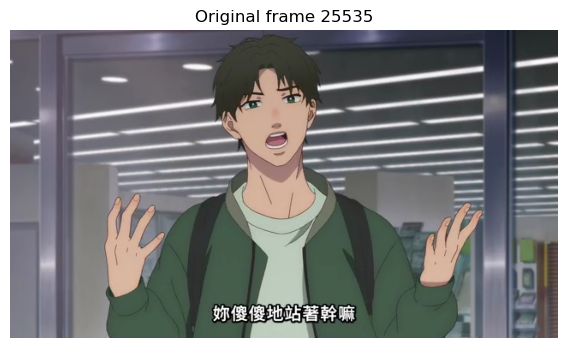

In [3]:
def read_frame_at(video_path, frame_id):
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = cap.read()
    cap.release()
    if not ret or frame is None:
        raise RuntimeError(f"Could not read frame {frame_id} from {video_path}")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


frame = read_frame_at(video_path, FRAME_ID)
H, W, _ = frame.shape

print("Frame shape:", frame.shape)
print("Min/Max:", frame.min(), frame.max())

plt.figure(figsize=(8, 4))
plt.imshow(frame)
plt.title(f"Original frame {FRAME_ID}")
plt.axis("off")
plt.show()

## 4) Build a tighter mask for the right hand / moving region

This mask is intentionally more accurate than the old centered black square. Adjust the coordinates if you want to cover a slightly different area. White = region to inpaint.


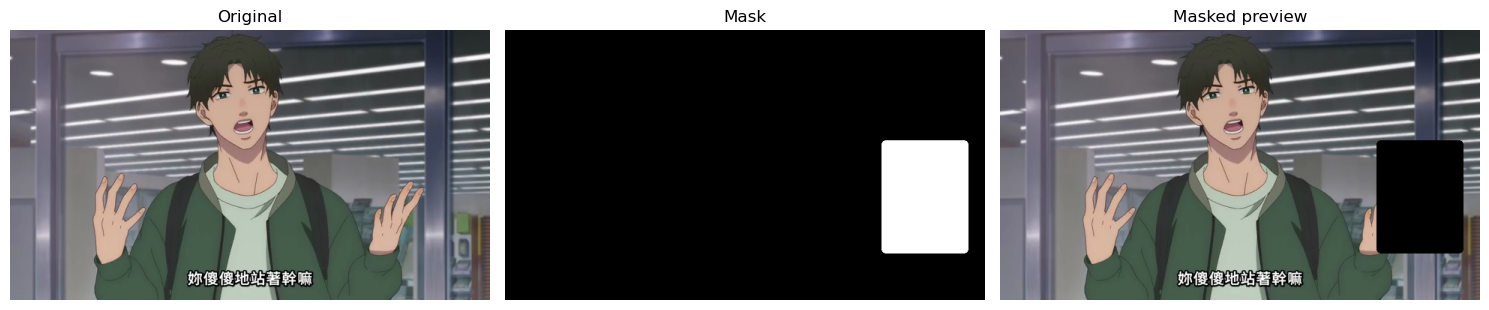

Frame size (W,H): 640 360
Mask unique values: [  0 255] ... [  0 255]


In [4]:
# Create a tighter, hand-focused mask.
# Coordinates are tuned for frame 25535 of 36877.mp4.
mask = np.zeros((H, W), dtype=np.uint8)

# Right hand region. Tweak these numbers if needed.
x1, x2 = 505, 615
y1, y2 = 150, 295

# Use a rounded/elliptical-ish mask instead of a harsh giant square.
# Start with a rectangle and soften the edges slightly.
mask[y1:y2, x1:x2] = 255

# Optional: make the mask less blocky by adding a slight blur.
# Keep this small so the mask still stays accurate.
mask_image_preview = Image.fromarray(mask).filter(ImageFilter.GaussianBlur(radius=2))
mask = np.array(mask_image_preview)
mask = (mask > 20).astype(np.uint8) * 255

masked_preview = frame.copy()
masked_preview[mask > 0] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(frame)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(masked_preview)
axes[2].set_title("Masked preview")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Frame size (W,H):", W, H)
print("Mask unique values:", np.unique(mask)[:10], "...", np.unique(mask)[-10:])

## 5) Convert frame and mask to PIL images


init_image size: (640, 360)
mask_image size: (640, 360)


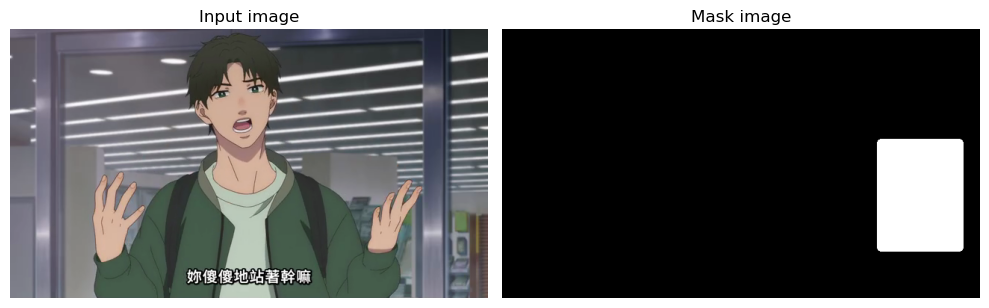

In [5]:
init_image = Image.fromarray(frame.astype(np.uint8)).convert("RGB")
mask_image = Image.fromarray(mask.astype(np.uint8)).convert("L")

print("init_image size:", init_image.size)
print("mask_image size:", mask_image.size)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(init_image)
plt.title("Input image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask_image, cmap="gray")
plt.title("Mask image")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6) Load Stable Diffusion inpainting pipeline

This uses the same route as the original Nintendo notebook. It will reuse your local Hugging Face cache if already available. It does **not** download base SD or AnimateDiff.


In [6]:
from diffusers import StableDiffusionInpaintPipeline

# Clear a little memory before loading.
gc.collect()
if device == "mps":
    torch.mps.empty_cache()

if "inpaint_pipe" in globals():
    print("Reusing already-loaded inpaint_pipe")
else:
    inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
        "stable-diffusion-v1-5/stable-diffusion-inpainting",
        torch_dtype=dtype,
        safety_checker=None,
        requires_safety_checker=False,
    )
    inpaint_pipe = inpaint_pipe.to(device)
    if device != "cpu":
        inpaint_pipe.enable_attention_slicing()
    print("Loaded inpaint_pipe")

print(type(inpaint_pipe))

W0423 23:57:29.436000 40777 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/Users/arushisingh/miniconda3/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/Users/arushisingh/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
vae/diffusion_pytorch_model.safetensors not found


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/Users/arushisingh/miniconda3/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Loaded inpaint_pipe
<class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'>


## 7) Single-frame inpainting test

This should preserve the rectangular frame shape. If your installed Diffusers version still returns a square image, the code resizes the output back for display/save.


  0%|          | 0/18 [00:00<?, ?it/s]

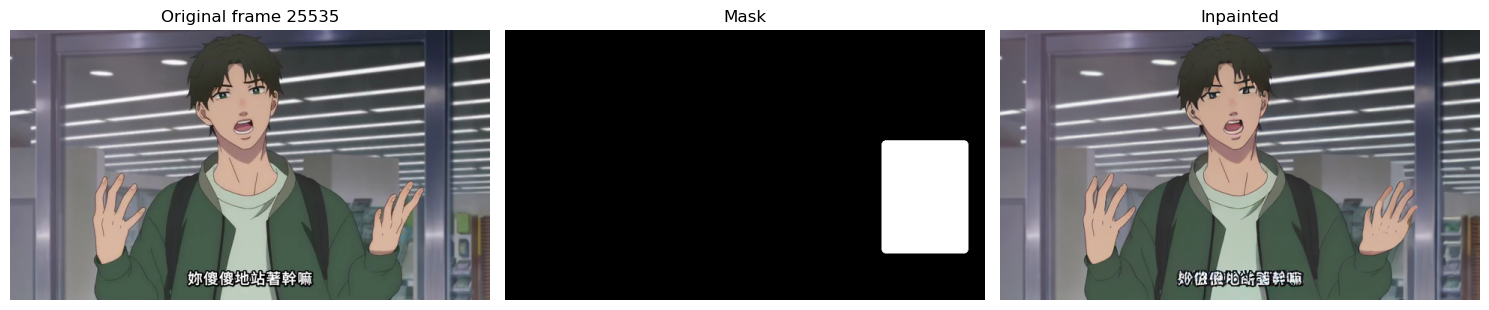

In [7]:
prompt = (
    "anime young man speaking indoors, expressive hands, clean anime linework, "
    "consistent character design, smooth shading, high quality"
)
negative_prompt = (
    "blurry, noisy, distorted, warped face, bad anatomy, extra fingers, extra hands, "
    "deformed hands, duplicate limbs, artifacts, text, watermark, worst quality"
)

# Important: pass height and width to avoid square output.
result = inpaint_pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=init_image,
    mask_image=mask_image,
    height=H,
    width=W,
    num_inference_steps=25,
    guidance_scale=7.5,
    strength=0.75,
).images[0]

# Safety: if the pipeline returns a square anyway, resize back to original aspect for consistency.
if result.size != init_image.size:
    print("Resizing result from", result.size, "to", init_image.size)
    result = result.resize(init_image.size, Image.Resampling.BICUBIC)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(init_image)
axes[0].set_title(f"Original frame {FRAME_ID}")
axes[0].axis("off")

axes[1].imshow(mask_image, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")

axes[2].imshow(result)
axes[2].set_title("Inpainted")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 8) Save single-frame result


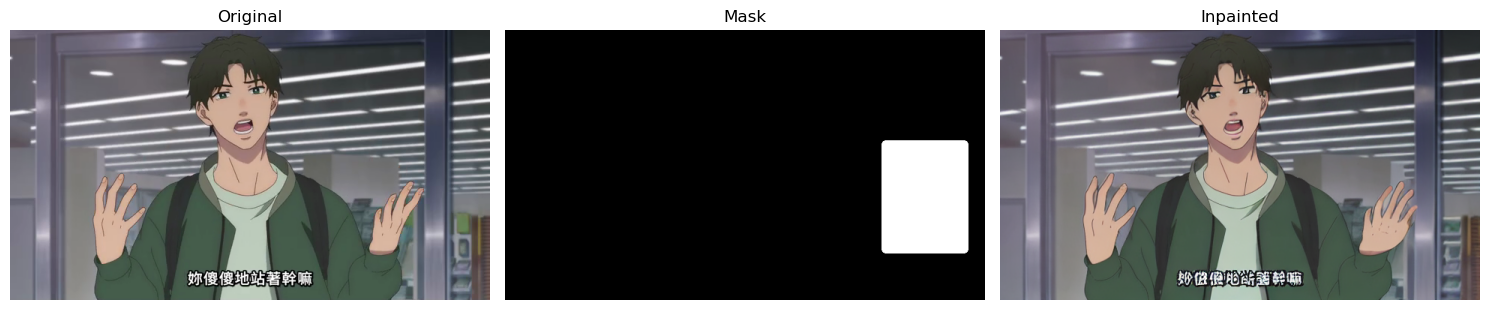

Saved result: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_frame_25535_inpaint.png
Saved comparison: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_frame_25535_comparison.png


In [8]:
single_path = OUTPUT_DIR / f"{video_path.stem}_frame_{FRAME_ID}_inpaint.png"
comparison_path = OUTPUT_DIR / f"{video_path.stem}_frame_{FRAME_ID}_comparison.png"

result.save(single_path)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(init_image)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(mask_image, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")
axes[2].imshow(result)
axes[2].set_title("Inpainted")
axes[2].axis("off")
plt.tight_layout()
plt.savefig(comparison_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved result:", single_path)
print("Saved comparison:", comparison_path)

## 9) Optional: nearby-frame GIF using the same mask

This follows the original notebook’s simple frame-by-frame method. It is optional, but useful for the report because it creates an actual GIF.


Loaded frames: [25527, 25529, 25531, 25533, 25535, 25537, 25539, 25541]


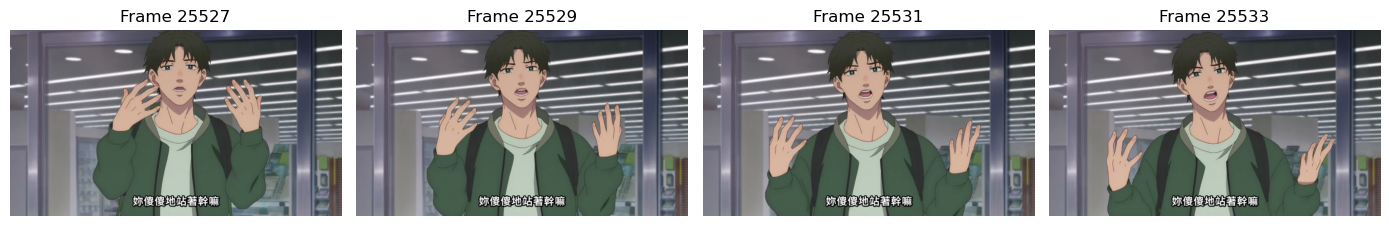

In [9]:
# Load a short window around the selected frame.
# Keep this small for speed.
NUM_FRAMES = 8
STRIDE = 2
START_FRAME = FRAME_ID - (NUM_FRAMES // 2) * STRIDE

segment_frames = []
segment_frame_ids = []
for k in range(NUM_FRAMES):
    fid = START_FRAME + k * STRIDE
    segment_frames.append(read_frame_at(video_path, fid))
    segment_frame_ids.append(fid)

print("Loaded frames:", segment_frame_ids)

sample_ids = list(range(min(4, len(segment_frames))))
fig, axes = plt.subplots(1, len(sample_ids), figsize=(14, 4))
if len(sample_ids) == 1:
    axes = [axes]
for ax, idx in zip(axes, sample_ids):
    ax.imshow(segment_frames[idx])
    ax.set_title(f"Frame {segment_frame_ids[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [10]:
from tqdm import tqdm
import imageio.v2 as imageio

# Reuse the exact same mask for the short GIF.
# This is the simple baseline method from the Nintendo notebook.
gif_results = []

for frame_np in tqdm(segment_frames):
    frame_pil = Image.fromarray(frame_np.astype(np.uint8)).convert("RGB")
    mask_pil = mask_image

    out = inpaint_pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=frame_pil,
        mask_image=mask_pil,
        height=H,
        width=W,
        num_inference_steps=20,
        guidance_scale=7.5,
        strength=0.75,
    ).images[0]

    if out.size != frame_pil.size:
        out = out.resize(frame_pil.size, Image.Resampling.BICUBIC)

    gif_results.append(out)

print("Finished GIF frames:", len(gif_results))

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [00:15<01:46, 15.25s/it]

  0%|          | 0/15 [00:00<?, ?it/s]

 25%|██▌       | 2/8 [00:30<01:31, 15.22s/it]

...

  0%|          | 0/15 [00:00<?, ?it/s]

 88%|████████▊ | 7/8 [01:46<00:15, 15.21s/it]

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 8/8 [02:01<00:00, 15.23s/it]

Finished GIF frames: 8


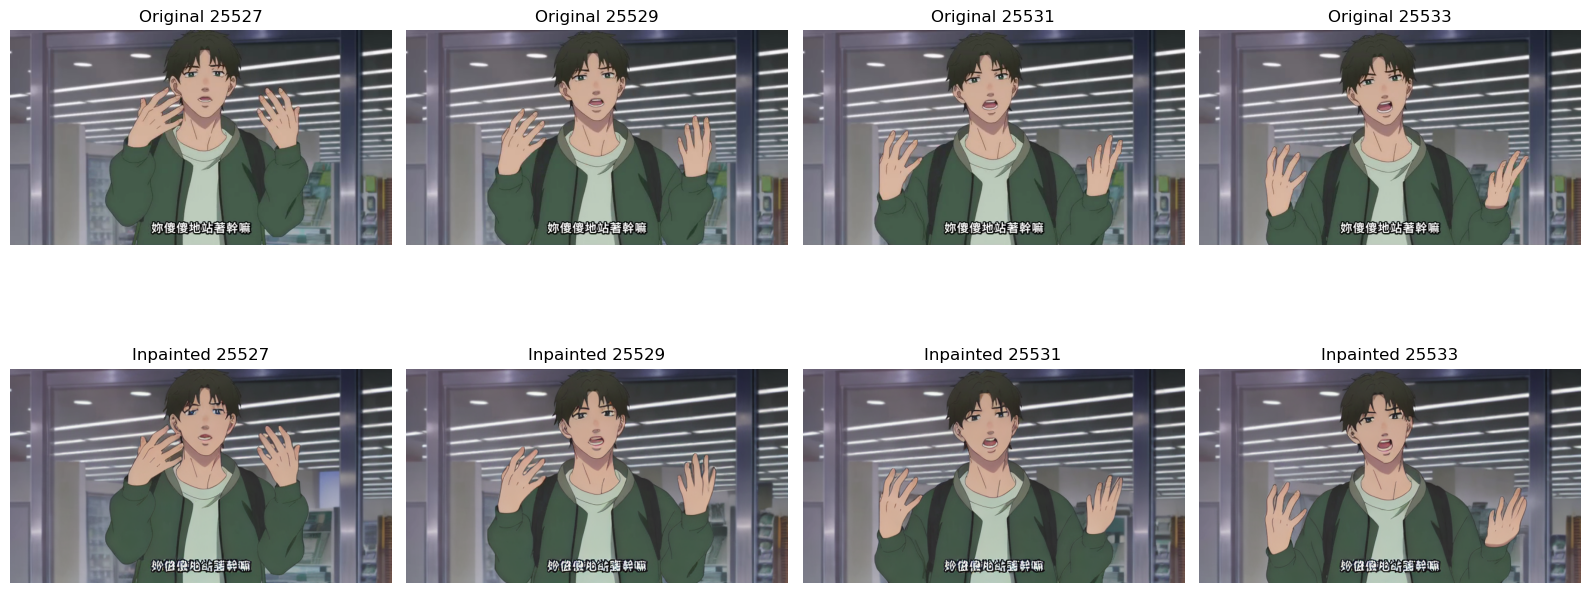

In [11]:
# Preview first few original vs inpainted frames
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    axes[0, i].imshow(segment_frames[i])
    axes[0, i].set_title(f"Original {segment_frame_ids[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(gif_results[i])
    axes[1, i].set_title(f"Inpainted {segment_frame_ids[i]}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

In [12]:
# Save GIF + MP4
from diffusers.utils import export_to_gif

baseline_gif = OUTPUT_DIR / f"{video_path.stem}_inpainting_baseline.gif"
baseline_mp4 = OUTPUT_DIR / f"{video_path.stem}_inpainting_baseline.mp4"

export_to_gif(gif_results, str(baseline_gif))

# MP4 export via imageio
imageio.mimsave(
    baseline_mp4,
    [np.array(img) for img in gif_results],
    fps=5,
    codec="libx264",
)

print("Saved GIF:", baseline_gif)
print("Saved MP4:", baseline_mp4)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (640, 360) to (640, 368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved GIF: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_inpainting_baseline.gif
Saved MP4: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_inpainting_baseline.mp4


## 10) Optional: simple temporal guidance comparison

This keeps the same idea from the original notebook: blend the previous output into the next input inside the masked region. It is not true AnimateDiff, but it is a simple guidance mechanism you can explain for Task III.


In [13]:
def blend_with_previous(current_frame_pil, prev_result_pil, mask_pil, alpha=0.7):
    prev_result_pil = prev_result_pil.resize(
        current_frame_pil.size, Image.Resampling.BILINEAR
    )

    current = np.array(current_frame_pil).astype(np.float32)
    prev = np.array(prev_result_pil).astype(np.float32)
    m = np.array(mask_pil).astype(np.float32) / 255.0
    m3 = np.repeat(m[:, :, None], 3, axis=2)

    guided = current * (1 - m3) + (alpha * prev + (1 - alpha) * current) * m3
    return Image.fromarray(np.clip(guided, 0, 255).astype(np.uint8))


def run_guided_inpainting(frames_list, alpha=0.7):
    guided_results = []

    for i, frame_np in enumerate(tqdm(frames_list)):
        frame_pil = Image.fromarray(frame_np.astype(np.uint8)).convert("RGB")

        if i == 0:
            guided_input = frame_pil
        else:
            guided_input = blend_with_previous(
                frame_pil, guided_results[-1], mask_image, alpha=alpha
            )

        out = inpaint_pipe(
            prompt=prompt,
            negative_prompt=negative_prompt,
            image=guided_input,
            mask_image=mask_image,
            height=H,
            width=W,
            num_inference_steps=20,
            guidance_scale=7.5,
            strength=0.75,
        ).images[0]

        if out.size != frame_pil.size:
            out = out.resize(frame_pil.size, Image.Resampling.BICUBIC)

        guided_results.append(out)

    return guided_results

In [14]:
alpha_values = [0.3, 0.7]
guided_experiments = {}

for alpha in alpha_values:
    print("Running alpha =", alpha)
    guided_experiments[alpha] = run_guided_inpainting(segment_frames, alpha=alpha)

print("Finished guided experiments")

Running alpha = 0.3


  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

 12%|█▎        | 1/8 [00:15<01:46, 15.28s/it]

  0%|          | 0/15 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

 88%|████████▊ | 7/8 [01:51<00:16, 16.03s/it]

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 8/8 [02:08<00:00, 16.00s/it]

Finished guided experiments


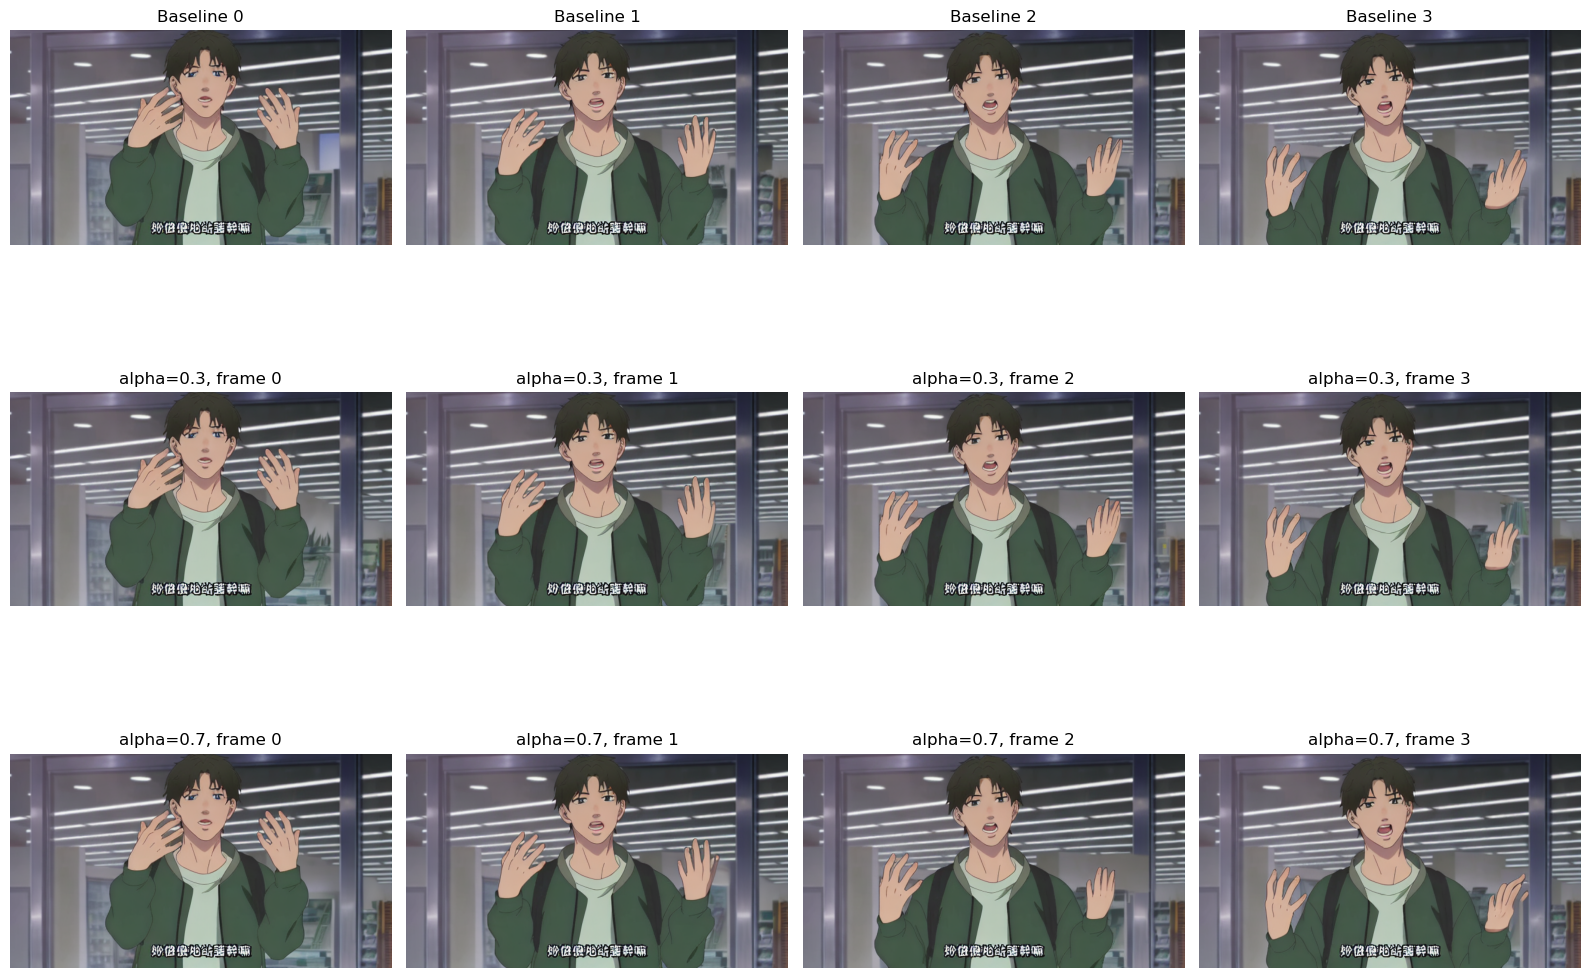

In [15]:
# Compare baseline and guided results
fig, axes = plt.subplots(
    1 + len(alpha_values), 4, figsize=(16, 4 * (1 + len(alpha_values)))
)

for i in range(4):
    axes[0, i].imshow(gif_results[i])
    axes[0, i].set_title(f"Baseline {i}")
    axes[0, i].axis("off")

for r, alpha in enumerate(alpha_values, start=1):
    for i in range(4):
        axes[r, i].imshow(guided_experiments[alpha][i])
        axes[r, i].set_title(f"alpha={alpha}, frame {i}")
        axes[r, i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for alpha, imgs in guided_experiments.items():
    tag = str(alpha).replace(".", "_")
    gif_path = OUTPUT_DIR / f"{video_path.stem}_guided_alpha_{tag}.gif"
    export_to_gif(imgs, str(gif_path))
    print("Saved:", gif_path)

# Save these to mp4 as well
for alpha, imgs in guided_experiments.items():
    tag = str(alpha).replace(".", "_")
    mp4_path = OUTPUT_DIR / f"{video_path.stem}_guided_alpha_{tag}.mp4"
    imageio.mimsave(
        mp4_path,
        [np.array(img) for img in imgs],
        fps=5,
        codec="libx264",
    )
    print("Saved:", mp4_path)

Saved: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_guided_alpha_0_3.gif


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (640, 360) to (640, 368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (640, 360) to (640, 368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_guided_alpha_0_7.gif
Saved: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_guided_alpha_0_3.mp4
Saved: /Users/arushisingh/deep-learning-video-inpainting-project/outputs/clean_inpainting/36877_guided_alpha_0_7.mp4
